# 

In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
from power_systems_ops.project1.read import login, read_tables, navigate

In [6]:
driver = login("coned@colorado.edu", "2025NYTeam")

using options


In [7]:
tables = read_tables(driver)

Power plant portfolio
Electricity generation and fuel consumption in the past round
Electricity production per plant
Power plant availability
Overview of power plants
Fuel characteristics
Coal
Biomass
Natural gas
Nuclear fuel
Wind availability
Solar
Electricity demand
Invest in a new power plant
Dismantle power plants
Offer a plant for sale
Plants currently offered for sale
Accept offered plant
Sold plants
Power exchange results
Your off-peak hour electricity bids
Your shoulder hour electricity bids
Your peak hour electricity bids
All off-peak hour electricity bids
All shoulder hour electricity bids
All peak hour electricity bids
Electricity demand function


In [149]:
tables.keys()

dict_keys(['dispatch', 'last_generation', 'overview', 'fuels', 'coal', 'biomass', 'naturalgas', 'nuclear', 'wind', 'solar', 'demand', 'invest', 'Dismantle power plants', 'Offer a plant for sale', 'Plants currently offered for sale', 'Accept offered plant', 'clearing_prices', 'Your off-peak hour electricity bids', 'Your shoulder hour electricity bids', 'Your peak hour electricity bids', 'All shoulder hour electricity bids', 'Electricity demand function'])

In [150]:
tables['overview']

,Company,Type,cap,Round active,Round dismantled,status
Plant name,,,,,,
R17 Solar,Duke Energy,solar,700.0,19,,operational
solar17,Xcel,solar,200.0,18,,operational
c15,AES,solar,700.0,18,,operational
c14,AES,wind,700.0,18,,operational
c13,AES,wind,500.0,17,,operational
...,...,...,...,...,...,...
e5,ConEd,naturalgasCCGT,300.0,-13,5,dismantled
a5,Xcel,naturalgasCCGT,600.0,-14,6,dismantled
d3,Dominion,powderCoal,600.0,-14,6,dismantled


In [153]:
help(tables['overview'].hist)

Help on method hist_frame in module pandas.plotting._core:

hist_frame(column: 'IndexLabel | None' = None, by=None, grid: 'bool' = True, xlabelsize: 'int | None' = None, xrot: 'float | None' = None, ylabelsize: 'int | None' = None, yrot: 'float | None' = None, ax=None, sharex: 'bool' = False, sharey: 'bool' = False, figsize: 'tuple[int, int] | None' = None, layout: 'tuple[int, int] | None' = None, bins: 'int | Sequence[int]' = 10, backend: 'str | None' = None, legend: 'bool' = False, **kwargs) method of pandas.core.frame.DataFrame instance
    Make a histogram of the DataFrame's columns.

    A `histogram`_ is a representation of the distribution of data.
    This function calls :meth:`matplotlib.pyplot.hist`, on each series in
    the DataFrame, resulting in one histogram per column.

    .. _histogram: https://en.wikipedia.org/wiki/Histogram

    Parameters
    ----------
    data : DataFrame
        The pandas object holding the data.
    column : str or sequence, optional
        I

In [200]:
ov = tables['overview']
for col in ['Round active', 'Round dismantled']:
    # ov[col] = pd.to_numeric(ov[col], errors='coerce').fillna(-1000).astype(int)
    ov[col] = pd.to_numeric(ov[col], errors='coerce').astype(float)


In [ ]:
ov['Ro

In [201]:
ov["Round dismantled"]

Plant name
R17 Solar   -1000.0
solar17     -1000.0
c15         -1000.0
c14         -1000.0
c13         -1000.0
              ...  
e5              5.0
a5              6.0
d3              6.0
c3              6.0
a6             19.0
Name: Round dismantled, Length: 112, dtype: float64

In [221]:
MIN_ROUND = 1
MAX_ROUND = 22
def positive_rounds(df):
    filtered = df
    # filtered = df[df.index > 0]
    full_index = range(MIN_ROUND, MAX_ROUND)
    return filtered.reindex(full_index, fill_value=0)

In [222]:
import matplotlib.pyplot as plt

In [227]:
from pathlib import Path
IMAGE_DIR = Path("/Users/sean/code/study-hard/power-systems-ops/latex/proj_1") / "Images"

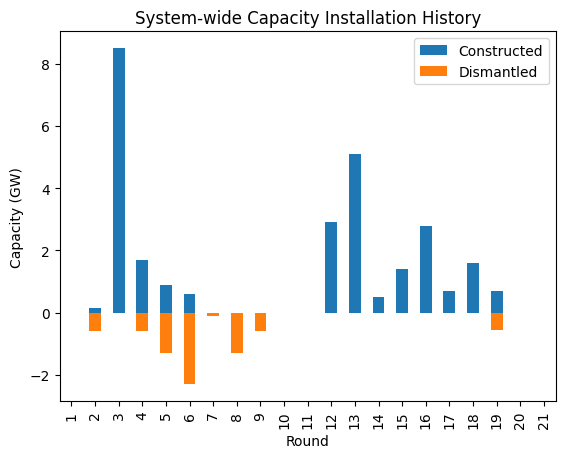

In [228]:
fig = plt.figure()
constructed = positive_rounds(ov.groupby('Round active').sum())
(constructed['cap'] / 1000).plot(kind='bar', color='C0', label="Constructed")

dismantled = positive_rounds(ov.groupby("Round dismantled").sum())
dismantled['cap'] = -dismantled['cap']
(dismantled['cap'] / 1000).plot(kind='bar', color='C1', label='Dismantled')
plt.legend()
plt.xlabel("Round")
plt.ylabel("Capacity (GW)")
plt.title("System-wide Capacity Installation History")
plt.axhline(y=
# plt.xticks(range(MIN_ROUND, MAX_ROUND, 2))

fig.savefig(IMAGE_DIR / "cap_install.png")

In [171]:
ov['Round dismantled']

Plant name
R17 Solar      
solar17        
c15            
c14            
c13            
             ..
e5            5
a5            6
d3            6
c3            6
a6           19
Name: Round dismantled, Length: 112, dtype: object

In [180]:
ov['Round dismantled'].astype(int)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

<Axes: xlabel='Round dismantled'>

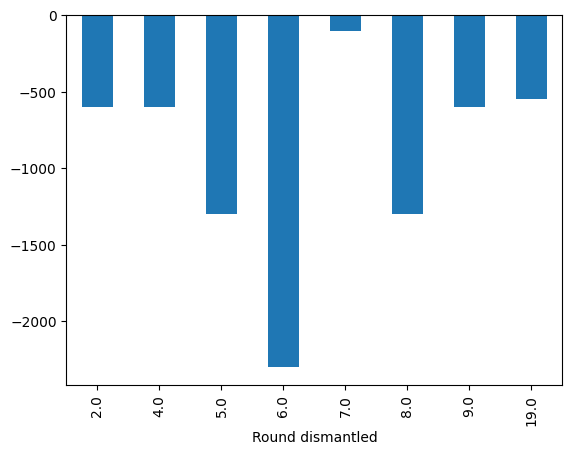

In [178]:
dismantled['cap'].plot(kind='bar', color=")

array([[<Axes: title={'center': 'cap'}>]], dtype=object)

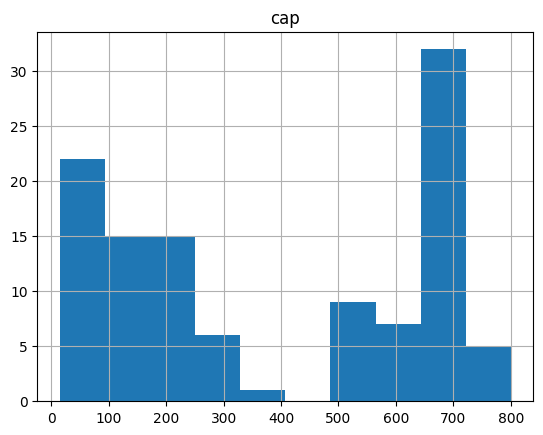

In [158]:
ov.hist('cap')

In [17]:
tables.keys()

dict_keys(['dispatch', 'last_generation', 'overview', 'fuels', 'coal', 'biomass', 'naturalgas', 'nuclear', 'wind', 'solar', 'demand', 'invest', 'Dismantle power plants', 'Offer a plant for sale', 'Plants currently offered for sale', 'Accept offered plant', 'clearing_prices', 'Your off-peak hour electricity bids', 'Your shoulder hour electricity bids', 'Your peak hour electricity bids', 'All shoulder hour electricity bids', 'Electricity demand function'])

In [ ]:
tables.hist(capacity, 

In [58]:
mu

array([0.57077626, 0.98173516])

In [18]:
tables['invest']

,Plant name,Type,rel,eff,construct,permit,life_exp,down,loan,num_loan,maint,cap_range,cap_range,Buy
0,,solar,96.0,0.0,1,1,25,0.084,0.033,15,0.019,100.00-700.00,,
1,,naturalgasCCGT,96.0,68.6,3,1,30,0.123,0.047,15,0.060,500.00-900.00,,
2,,naturalgasOCGT,96.0,44.2,2,0,30,0.094,0.049,10,0.024,100.00-500.00,,
3,,powderCoal,96.0,45.5,4,1,40,0.227,0.073,20,0.116,400.00-1000.00,,
4,,wind,96.0,NaN,1,1,25,0.264,0.102,15,0.045,100.00-700.00,,
5,,nuclear,96.0,34.7,5,2,50,1.200,0.385,20,0.106,900.00-1300.00,,
6,,biomass,96.0,45.5,4,1,40,0.243,0.078,20,0.125,400.00-1000.00,,


In [57]:
volume = [
    # Time per period in hr
    5000, 3600, 160
]
mu =  np.cumsum([v / sum(volume) for v in volume])[:2]

In [19]:
invest = tables['invest'].set_index("Type")

In [60]:
cap = invest['down'] + invest['loan'] * invest['num_loan']

In [61]:
cap

Type
solar             0.579
naturalgasCCGT    0.828
naturalgasOCGT    0.584
powderCoal        1.687
wind              1.794
nuclear           8.900
biomass           1.803
dtype: float64

In [22]:
r = invest.loc['solar']

In [24]:
cap = r['down'] + r['loan'] * r['num_loan']

In [44]:
from power_systems_ops.project1.costs import compute_fuel_costs

In [64]:
approx_round = 8

In [65]:
fuel = compute_fuel_costs(tables, invest['eff'], invest.index, round=approx_round)

8
8
8
8
8
Index([0.0, 0.23, 0.23, 77.15, 0.0, 1605.06, 35.44], dtype='float64', name='Type')


In [70]:
beta = {
    f: np.mean(tables[f][tables[f].index < approx_round]['avail']) / 100
    if f in ['solar', 'wind'] else 1
    for f in fuel.index
}
beta = pd.Series(beta)

In [71]:
beta

solar             0.302308
naturalgasCCGT    1.000000
naturalgasOCGT    1.000000
powderCoal        1.000000
wind              0.586923
nuclear           1.000000
biomass           1.000000
dtype: float64

In [59]:
fuel

Type
solar              0.000000
naturalgasCCGT    34.417779
naturalgasOCGT    53.417639
powderCoal        24.416703
wind               0.000000
nuclear            4.282901
biomass           18.090606
dtype: float64

In [74]:
fuel / cap

Type
solar              0.000000
naturalgasCCGT    41.567366
naturalgasOCGT    91.468559
powderCoal        14.473446
wind               0.000000
nuclear            0.481225
biomass           10.033614
dtype: float64

In [138]:
r = 0.9
mu = [1, 0.429]


In [145]:
def breakeven_price(fuel, r, beta, mu, cap, life, maint):
    return fuel + 1 / r / beta / mu / 8760 * (cap / life + maint) * 1e6

In [140]:
p_e_1 = fuel + 1 / r / beta / mu[0] / 8760 * (cap / invest['life_exp'] + invest['maint']) * 1e6
p_e_1 = fuel + 1 / r / beta / mu[0] / 8760 * (cap / invest['life_exp'] + invest['maint']) * 1e6
p_e_2 = fuel + 1 / r / beta / mu[1] / 8760 * (cap / invest['life_exp'] + invest['maint']) * 1e6

In [146]:
n_invest = invest.loc['nuclear']
nuclear_investment = 0.500 + 5 * n_invest['loan']
maint = n_invest['maint']
life_exp = n_invest['life_exp'] - 14

breakeven_price(fuel.loc['nuclear'], r, beta['nuclear'], mu[0], nuclear_investment, life_exp, maint)

np.float64(26.271880142306802)

In [147]:
breakeven_price(fuel.loc['nuclear'], r, beta['nuclear'], mu[1], nuclear_investment, life_exp, maint)

np.float64(55.539262561642545)

In [144]:
print(nuclear_investment

2.425


In [123]:
p_e_1

Type
solar             17.689061
naturalgasCCGT    45.528890
naturalgasOCGT    58.930914
powderCoal        44.479489
wind              25.232849
nuclear           40.305225
biomass           39.662778
dtype: float64

In [124]:
fuel

Type
solar              0.000000
naturalgasCCGT    34.417779
naturalgasOCGT    53.417639
powderCoal        24.416703
wind               0.000000
nuclear            4.282901
biomass           18.090606
dtype: float64

In [125]:
for row in projections:
    print(row)

cap
lifetime
renew
Fuel cost
p_1
p_2


In [126]:
projections = pd.DataFrame(
    data={
        "cap": cap,
        "lifetime": invest['life_exp'],
        "renew": beta,
        "Fuel cost": fuel,
        "p_1": p_e_1,
        "p_2": p_e_2,
    },
    index=fuel.index
)
print(projections)

                  cap  lifetime     renew  Fuel cost        p_1        p_2
Type                                                                      
solar           0.579        25  0.302308   0.000000  17.689061  41.233243
naturalgasCCGT  0.828        30  1.000000  34.417779  45.528890  60.317805
naturalgasOCGT  0.584        30  1.000000  53.417639  58.930914  66.269097
powderCoal      1.687        40  1.000000  24.416703  44.479489  71.183103
wind            1.794        25  0.586923   0.000000  25.232849  58.817829
nuclear         8.900        50  1.000000   4.282901  40.305225  88.251022
biomass         1.803        40  1.000000  18.090606  39.662778  68.375388


In [127]:
projections.round(2)

,cap,lifetime,renew,Fuel cost,p_1,p_2
Type,,,,,,
solar,0.58,25,0.30,0.00,17.69,41.23
naturalgasCCGT,0.83,30,1.00,34.42,45.53,60.32
naturalgasOCGT,0.58,30,1.00,53.42,58.93,66.27
powderCoal,1.69,40,1.00,24.42,44.48,71.18
wind,1.79,25,0.59,0.00,25.23,58.82
nuclear,8.90,50,1.00,4.28,40.31,88.25
biomass,1.80,40,1.00,18.09,39.66,68.38


In [128]:
(8760 - 5000) / 8760

0.4292237442922374

In [129]:
    latex_rows = middle_df.to_latex(index=True, header=False, escape=False, float_format=f"%.{decimals}f").split("\n")[3:-3]

NameError: name 'middle_df' is not defined

In [131]:
for r in projections.sort_values(by='p_1').to_latex(index=True, header=True, escape=False, float_format="%.2f").split('\n'):
    print(r)

\begin{tabular}{lrrrrrr}
\toprule
 & cap & lifetime & renew & Fuel cost & p_1 & p_2 \\
Type &  &  &  &  &  &  \\
\midrule
solar & 0.58 & 25 & 0.30 & 0.00 & 17.69 & 41.23 \\
wind & 1.79 & 25 & 0.59 & 0.00 & 25.23 & 58.82 \\
biomass & 1.80 & 40 & 1.00 & 18.09 & 39.66 & 68.38 \\
nuclear & 8.90 & 50 & 1.00 & 4.28 & 40.31 & 88.25 \\
powderCoal & 1.69 & 40 & 1.00 & 24.42 & 44.48 & 71.18 \\
naturalgasCCGT & 0.83 & 30 & 1.00 & 34.42 & 45.53 & 60.32 \\
naturalgasOCGT & 0.58 & 30 & 1.00 & 53.42 & 58.93 & 66.27 \\
\bottomrule
\end{tabular}



In [90]:
p_e_2

Type
solar             18.018160
naturalgasCCGT    45.735608
naturalgasOCGT    59.033487
powderCoal        44.852750
wind              25.702297
nuclear           40.975408
biomass           40.064120
dtype: float64

In [43]:

np.mean(tables['solar'][tables['wind'].index < 10]['avail'])

np.float64(30.666666666666668)

In [ ]:
np.

In [39]:
tables['wind']

,avail
Round,
21,24.0
20,52.0
19,75.0
18,48.0
17,56.0
16,69.0
15,57.0
14,58.0
13,39.0


In [25]:
'solar'

np.float64(0.579)

In [8]:
tables['clearing_prices']

,round,offpeak_demand,offpeak_price,shoulder_demand,shoulder_price,peak_demand,peak_price
0,20,11935.90,3.70,14386.22,24.73,15399.40,189.48
1,19,11424.83,0.00,13926.68,3.70,16352.54,15.00
2,18,11101.43,3.77,13247.07,36.74,14000.60,208.92
3,17,10914.49,3.81,12934.82,45.17,14820.41,100.00
4,16,10875.96,3.81,12785.11,55.43,13257.55,250.72
5,15,10494.68,30.00,12107.85,108.56,12307.85,328.45
6,14,10202.91,35.00,11231.70,166.63,11516.70,372.64
7,13,9792.66,60.03,10690.51,201.20,10739.55,427.25
8,12,10325.87,18.97,11746.00,110.64,11981.00,320.82
9,11,10263.19,23.32,11134.02,169.49,11558.00,360.34


In [218]:
# Calculation inputs
plant_name = 'e7'
calc_round = 5   # Used for prices
capacity_factor_by_period = [0, 0, 1]

In [219]:
price_table = tables['clearing_prices'].set_index("round")
price_table

,offpeak_demand,offpeak_price,shoulder_demand,shoulder_price,peak_demand,peak_price
round,,,,,,
5,9227.05,25.00,11263.07,32.00,13239.08,45.00
4,9203.66,25.75,11227.64,33.60,13199.12,46.70
3,9061.69,19.87,11032.26,28.60,13011.12,36.50
2,8719.92,42.68,10569.30,61.00,10940.05,227.19
1,8738.00,26.20,10695.80,30.42,12530.00,47.00


In [220]:
periods = ['offpeak', 'shoulder', 'peak']
column_names = [f'{period}_price' for period in periods]
prices = [price_table.loc[calc_round][k] for k in column_names]

In [221]:
print(prices)

[np.float64(25.0), np.float64(32.0), np.float64(45.0)]


In [222]:
volume_by_period = [5000, 3600, 160]

In [223]:
d = tables['dispatch']
d

,type,cap,rel,eff,loan,payments,fixed,status,first_round,priority
Name,,,,,,,,,,
e9,solar,20.0,90.3,0.00,1.4,6,0.4,available,-3,1
inv-solar-3,solar,700.0,94.2,0.00,40.6,12,14.0,available,3,2
e4,wind,150.0,94.4,NaN,30.7,8,7.1,available,-1,3
e3,wind,50.0,94.7,NaN,9.9,9,2.4,available,0,4
e1,nuclear,800.0,91.9,33.53,308.1,5,92.5,available,-9,5
e2,powderCoal,700.0,94.8,40.19,65.5,14,85.6,available,0,6
e10,biomass,90.0,95.2,40.59,8.8,16,11.8,available,2,7
e6,naturalgasCCGT,600.0,92.9,53.99,38.5,3,39.5,available,-6,8
e8,naturalgasOCGT,50.0,93.3,37.40,3.2,0,1.3,available,-5,9


In [10]:
import pandas as pd
import numpy as np

In [15]:
invest_table = pd.DataFrame([
        ['e9', 	'solar', 	20.0, 	90.3, 	0.00, 	1.4, 	6, 	0.4, 	'available', 	-3, 	1],
        ['inv-solar-3', 	'solar', 	700.0, 	94.2, 	0.00, 	40.6, 	12, 	14.0, 	'available', 	3, 	2],
        ['e4', 	'wind', 	150.0, 	94.4, 	np.nan, 	30.7, 	8, 	7.1, 	'available', 	-1, 	3,],
        ['e3', 	'wind', 	50.0, 	94.7, 	np.nan, 	9.9, 	9, 	2.4, 	'available', 	0, 	4,],
        ['e1', 	'nuclear', 	800.0, 	91.9, 	33.53, 	308.1, 	5, 	92.5, 	'available', 	-9, 	5,],
        ['e2', 	'powderCoal', 	700.0, 	94.8, 	40.19, 	65.5, 	14, 	85.6, 	'available', 	0, 	6,],
        ['e10', 	'biomass', 	90.0, 	95.2, 	40.59, 	8.8, 	16, 	11.8, 	'available', 	2, 	7,],
        ['e6', 	'naturalgasCCGT', 	600.0, 	92.9, 	53.99, 	38.5, 	3, 	39.5, 	'available', 	-6, 	8,],
        ['e8', 	'naturalgasOCGT', 	50.0, 	93.3, 	37.40, 	3.2, 	0, 	1.3, 	'available', 	-5, 	9,],
        ['e7', 	'naturalgasOCGT', 	50.0, 	90.5, 	36.08, 	3.4, 	0, 	1.4, 	'available', 	-11, 	10,],
        ['e5', 	'naturalgasCCGT', 	300.0, 	np.nan, 	51.06, 	20.6, 	0, 	np.nan, 	'dismantled', 	-13, 	11,],
    ],
    columns=['Name', 'type', 	'cap', 	'rel', 	'eff', 	'loan', 	'payments', 	'fixed', 	'status', 	'first_round', 	'priority'],
)
invest_table = invest_table.set_index("Name")

In [16]:
invest_table

,type,cap,rel,eff,loan,payments,fixed,status,first_round,priority
Name,,,,,,,,,,
e9,solar,20.0,90.3,0.00,1.4,6,0.4,available,-3,1
inv-solar-3,solar,700.0,94.2,0.00,40.6,12,14.0,available,3,2
e4,wind,150.0,94.4,NaN,30.7,8,7.1,available,-1,3
e3,wind,50.0,94.7,NaN,9.9,9,2.4,available,0,4
e1,nuclear,800.0,91.9,33.53,308.1,5,92.5,available,-9,5
e2,powderCoal,700.0,94.8,40.19,65.5,14,85.6,available,0,6
e10,biomass,90.0,95.2,40.59,8.8,16,11.8,available,2,7
e6,naturalgasCCGT,600.0,92.9,53.99,38.5,3,39.5,available,-6,8
e8,naturalgasOCGT,50.0,93.3,37.40,3.2,0,1.3,available,-5,9


In [224]:
invest_table = tables['invest'].set_index("Type")

In [225]:
current = tables['dispatch'].loc[plant_name]
projected = invest_table.loc[current['type']]

In [226]:
cap = current['cap']
reliability = current['rel'] / 100
loan = current['loan']
loan_payments = current['payments']
fixed = current['fixed']
life_exp = projected['life_exp']

In [227]:
# Expected revenue (assuming constant reliability...) in Million Euros
exp_rev_by_period = [cap * price * volume * reliability * cap_factor / 1e6
                     for price, volume, cap_factor in zip(
                         prices, volume_by_period, capacity_factor_by_period)]
exp_rev = sum(exp_rev_by_period)

In [228]:
# Peaker plant retirement, assuming 100% reliability and 100% capacity factor at peak
# and 0% at lower load, what price do we need to break even?
i_peak = periods.index('peak')
# unit check: (M euro/year) * (1/MW) * (1 / hr) * (1e6Euro / 1M euro)
breakeven_price = fixed / (cap * volume_by_period[i_peak]) * 1e6
print(breakeven_price)

175.0


In [229]:
cap * volume / 1e6

NameError: name 'volume' is not defined

In [193]:
print(exp_rev_by_period)
print('total:', exp_rev)

[np.float64(0.0), np.float64(0.0), np.float64(0.3258)]
total: 0.3258


In [194]:
first_round = current['first_round']
current_round = 6
age = current_round - first_round
remaining_life = life_exp - age

In [195]:
expenditures = [ loan + fixed ] * loan_payments + [fixed] * (remaining_life - loan_payments)
expenditures = np.array(expenditures)

In [196]:
rev_over_time = [exp_rev] * remaining_life
rev_over_time = np.array(rev_over_time)

In [197]:
# initial_cost = 400
# expenditures[0] += initial_cost

In [198]:
cash_flow = np.cumsum(rev_over_time - expenditures)

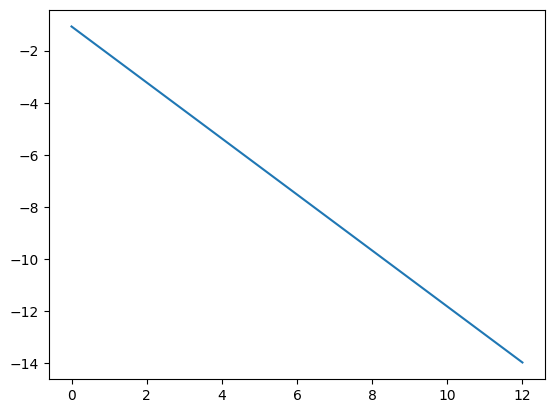

In [199]:
plt.plot(cash_flow)

In [ ]:
cash_flow = 

In [128]:
exp_rev * remaining_life

np.float64(6366.0968)

In [126]:
sum(expenditures)

np.float64(4778.0)

In [125]:
import matplotlib.pyplot as plt

In [124]:
print(expenditures)

[np.float64(400.6), np.float64(400.6), np.float64(400.6), np.float64(400.6), np.float64(400.6), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5)]


In [93]:
cap

np.float64(800.0)

In [ ]:
yearly_exp = 

In [80]:
tables['dispatch'].loc[tab

,type,cap,rel,eff,loan,payments,fixed,status,first_round,priority
Name,,,,,,,,,,
e9,solar,20.0,90.3,0.00,1.4,6,0.4,available,-3,1
inv-solar-3,solar,700.0,94.2,0.00,40.6,12,14.0,available,3,2
e4,wind,150.0,94.4,NaN,30.7,8,7.1,available,-1,3
e3,wind,50.0,94.7,NaN,9.9,9,2.4,available,0,4
e1,nuclear,800.0,91.9,33.53,308.1,5,92.5,available,-9,5
e2,powderCoal,700.0,94.8,40.19,65.5,14,85.6,available,0,6
e10,biomass,90.0,95.2,40.59,8.8,16,11.8,available,2,7
e6,naturalgasCCGT,600.0,92.9,53.99,38.5,3,39.5,available,-6,8
e8,naturalgasOCGT,50.0,93.3,37.40,3.2,0,1.3,available,-5,9


In [62]:
prices.loc[5]

offpeak_demand      9227.05
offpeak_price         25.00
shoulder_demand    11263.07
shoulder_price        32.00
peak_demand        13239.08
peak_price            45.00
Name: 5, dtype: float64

In [10]:
from selenium.webdriver.common.by import By

In [12]:
ts = driver.find_elements(By.XPATH, "//div[@class='component table left white']")

In [15]:
for t in ts[:1]:
    print(t.find_element(By.TAG_NAME, 'h4').text)

Power exchange results


In [17]:
table_header = ts[0].find_element(By.TAG_NAME, 'thead')

In [27]:
hs = table_header.find_element(By.TAG_NAME, 'tr').find_elements(By.TAG_NAME, 'th')

In [28]:
for h in hs:
    print(h.get_attribute("colspan"))

None
2
2
2


In [23]:
h.text

'Period'

In [6]:
tables.keys()

dict_keys(['dispatch', 'last_generation', 'overview', 'fuels', 'coal', 'biomass', 'naturalgas', 'nuclear', 'wind', 'solar', 'demand', 'invest', 'Dismantle power plants', 'Offer a plant for sale', 'Plants currently offered for sale', 'Accept offered plant'])

In [7]:
tables['dispatch']

,type,cap,rel,eff,loan,payments,fixed,status,first_round,priority
Name,,,,,,,,,,
e9,solar,20.0,90.3,0.00,1.4,6,0.4,available,-3,1
inv-solar-3,solar,700.0,94.2,0.00,40.6,12,14.0,available,3,2
e4,wind,150.0,94.4,NaN,30.7,8,7.1,available,-1,3
e3,wind,50.0,94.7,NaN,9.9,9,2.4,available,0,4
e1,nuclear,800.0,91.9,33.53,308.1,5,92.5,available,-9,5
e2,powderCoal,700.0,94.8,40.19,65.5,14,85.6,available,0,6
e10,biomass,90.0,95.2,40.59,8.8,16,11.8,available,2,7
e6,naturalgasCCGT,600.0,92.9,53.99,38.5,3,39.5,available,-6,8
e8,naturalgasOCGT,50.0,93.3,37.40,3.2,0,1.3,available,-5,9


In [8]:
driver.quit()

In [ ]:
tables['

In [ ]:
tables